# Universidad Nacional Autónoma de México

# Facultad de Ingeniería

## Minería de Datos - Gpo. 3 - 2027-1

### Práctica 3.1: Agrupación

#### Equipo 4: 
- Echevarría Aguilar Luis Ángel
- Lee Robles Leonardo Alan
- Luna Darwin

## 1. Descripción del caso y objetivo

**Caso.** Se cuenta con el historial de **transacciones de ventas** (enero 2014 – diciembre 2016) de una empresa de alimentos (carnes frías, quesos, yoghurt, cremas, comidas preparadas, etc.) que vende a **empleados de empresas corporativas** (18 empresas, 524 clientes). Cada fila del archivo es una *línea de producto* dentro de una transacción e incluye datos del producto, del precio y de la persona que compra (edad, sexo, estado civil, hijos, antigüedad, puesto, estado).

**Problema.** Hoy la empresa trata a todos los clientes igual, aunque su frecuencia de compra, gasto, uso de descuentos y tipo de producto que prefieren son muy distintos. No existe una etiqueta que indique a qué tipo de cliente pertenece cada persona, por lo que se requiere un **aprendizaje no supervisado**.

**Objetivo.** Aplicar algoritmos de **agrupación (clustering)** – K-Means, DBSCAN y un tercer algoritmo – para **segmentar a los clientes** en grupos con comportamiento de compra y perfil demográfico similares. Los segmentos permitirán:
- diseñar promociones y descuentos dirigidos,
- identificar a los clientes de mayor valor y a los de baja frecuencia,
- orientar el surtido de productos por perfil.

**Unidad de análisis.** El archivo original está a nivel *línea de transacción* (58,903 filas). Para segmentar clientes se **agrega a nivel cliente** (una fila por `Clave_Cliente`), construyendo variables tipo **RFM** (recencia, frecuencia, monto) y de mezcla de producto, más las variables demográficas.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50, "display.width", 160)

RUTA = "Transacciones_de_ventas Practica.csv"
raw = pd.read_csv(RUTA, encoding="latin-1")
print("Dimensiones:", raw.shape)
raw.head()

Dimensiones: (58903, 33)


,Sector,Tipo,Linea,Sublinea,Presentacion,Gramaje,Empresa,Año,Fecha,Cliente,Transaccion,Pedido,Control,Producto,Descripcion,Unidad,Cantidad,Precio,Precio_Max,Dif_PrecioMax,Importe,Clave_Cliente,No._Hijos,Antiguedad,Edad,Edad_Rango,Escolaridad,Estado_Civil,Estado,Sexo,Funcion,Grupo,Reg
0,OTROS,PROLIVO,ACEITES Y MANTECAS,ACEITE DE OLIVA,PAQUETERIA,2.29,957936 ALFA TORRE,2015,04-12-15,126306 LAURA IS,571707,100503,9995,9995,ACEITE DE OLIVA PROLIVO BISTRO 2.5LT,PZ,1,211.5,211.5,0.0,211.5,126306,0,27,46,40 - 49,Sin asignar,Casado,Nuevo Leon,Femenino,GENERICO,EMPLEADOS,1
1,OTROS,PROLIVO,ACEITES Y MANTECAS,ACEITE DE OLIVA,PAQUETERIA,2.29,957936 ALFA TORRE,2016,14-01-16,206654 ROBERTO,573734,102430,9995,9995,ACEITE DE OLIVA PROLIVO BISTRO 2.5LT,PZ,1,211.5,211.5,0.0,211.5,206654,0,2,25,< 30,Licenciatura,Soltero,Nuevo Leon,Masculino,EMPLEADO A,EMPLEADOS,1
2,OTROS,PROLIVO,ACEITES Y MANTECAS,ACEITE DE OLIVA,PAQUETERIA,2.29,303012 CORPORATIVO BETA COMERCIAL,2016,13-06-16,203171 LILIANA,579968,108728,9995,9995,ACEITE DE OLIVA PROLIVO BISTRO 2.5LT,PZ,1,211.5,211.5,0.0,211.5,203171,0,2,29,< 30,Licenciatura,Soltero,Nuevo Leon,Femenino,OFICINISTA B,EMPLEADOS,1
3,OTROS,PROLIVO,ACEITES Y MANTECAS,ACEITE DE OLIVA,PAQUETERIA,2.29,957936 ALFA TORRE,2016,14-06-16,220447 ADALILIA,580011,108781,9995,9995,ACEITE DE OLIVA PROLIVO BISTRO 2.5LT,PZ,1,211.5,211.5,0.0,211.5,220447,0,1,27,< 30,Sin asignar,Soltero,Nuevo Leon,Femenino,OFICINISTA A,EMPLEADOS,1
4,OTROS,PROLIVO,ACEITES Y MANTECAS,ACEITE DE OLIVA,PAQUETERIA,2.29,436463 ALFA CARRIZALEJO,2016,01-07-16,111027 URIEL IV,580710,109440,9995,9995,ACEITE DE OLIVA PROLIVO BISTRO 2.5LT,PZ,1,211.5,211.5,0.0,211.5,111027,0,12,35,30 - 39,Pasante,Soltero,Nuevo Leon,Masculino,EMPLEADO A,EMPLEADOS,1


## 2. Variables participantes, limpieza y transformación

### 2.1 Diccionario de variables
| Grupo | Variables | Tipo |
|---|---|---|
| Producto (jerarquía) | `Sector` > `Tipo` > `Linea` > `Sublinea`, `Presentacion`, `Gramaje`, `Producto`/`Control`, `Descripcion`, `Unidad` | Categóricas / ID / numérica (`Gramaje`) |
| Transacción | `Transaccion`, `Pedido`, `Fecha`, `Año`, `Empresa` | ID / temporal / categórica |
| Venta | `Cantidad`, `Precio`, `Precio_Max`, `Dif_PrecioMax`, `Importe` | Numéricas |
| Cliente | `Clave_Cliente`, `Cliente`, `Edad`, `Edad_Rango`, `Sexo`, `Estado_Civil`, `No._Hijos`, `Escolaridad`, `Estado`, `Antiguedad`, `Funcion`, `Grupo` | ID / numéricas / categóricas |
| Sin información | `Reg` (constante = 1) | — |

### 2.2 Diagnóstico de calidad (antes de limpiar)

In [2]:
diag = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "unicos": raw.nunique(),
})
print("Filas duplicadas:", raw.duplicated().sum())
display(diag)

print("\nUnidad:", raw.Unidad.value_counts().to_dict())
print("'Sin asignar' en Escolaridad: %.1f%%" % ((raw.Escolaridad == "Sin asignar").mean()*100))
print("Estado_Civil 'Sin asignar':", (raw.Estado_Civil == "Sin asignar").sum(),
      "| Presentacion 'Sin asignar':", (raw.Presentacion == "Sin asignar").sum())
print("Texto con codificación rota en Descripcion:", raw.Descripcion.str.contains("Ã|ï¿½").sum(), "filas")
print("Precio > Precio_Max:", (raw.Precio > raw.Precio_Max).sum(), "filas")
print("Importe == Cantidad*Precio:", np.isclose(raw.Importe, raw.Cantidad*raw.Precio, atol=0.05).mean())
print("Dif_PrecioMax == Precio_Max-Precio:", np.isclose(raw.Dif_PrecioMax, raw.Precio_Max-raw.Precio, atol=0.05).mean())

Filas duplicadas: 0


,tipo,nulos,unicos
Sector,str,0,12
Tipo,str,0,43
Linea,str,0,60
Sublinea,str,0,96
Presentacion,str,0,6
Gramaje,float64,0,93
Empresa,str,0,18
Año,int64,0,3
Fecha,str,0,777
Cliente,str,0,561



Unidad: {'PZ': 48852, 'pz': 9997, 'kg': 52, 'KG': 2}
'Sin asignar' en Escolaridad: 86.1%
Estado_Civil 'Sin asignar': 812 | Presentacion 'Sin asignar': 29
Texto con codificación rota en Descripcion: 1622 filas
Precio > Precio_Max: 121 filas
Importe == Cantidad*Precio: 1.0
Dif_PrecioMax == Precio_Max-Precio: 1.0


### 2.3 Limpieza

In [3]:
df = raw.copy()

# (a) Codificación: el archivo mezcla Latin-1 con UTF-8 mal interpretado (ESPAÃ\x91OL -> ESPAÑOL)
def arregla(s):
    try:    return s.encode("latin-1").decode("utf-8")
    except Exception: return s
for c in ["Descripcion", "Cliente"]:
    df[c] = df[c].map(arregla)
df["Descripcion"] = (df["Descripcion"]
    .str.replace("CAMPOFRÃ�O", "CAMPOFRIO", regex=False)   # el carácter original se perdió en el archivo
    .str.replace("HERSHEYÂ´S", "HERSHEYS", regex=False))

# (b) Espacios sobrantes / dobles
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].str.strip().str.replace(r"\s+", " ", regex=True)

# (c) Homologar categorías
df["Unidad"] = df["Unidad"].str.upper()
df["Sector"] = df["Sector"].replace({"MNTQUILLAS Y MARGARI": "MANTEQUILLAS Y MARGARINAS"})
df["Sublinea"] = df["Sublinea"].replace({"SALCHICHA TRADICIONA": "SALCHICHA TRADICIONAL"})
df["Grupo"] = df["Grupo"].replace({"DIRECTIVOES": "DIRECTIVOS"})
df["Escolaridad"] = df["Escolaridad"].replace({"sin titulacion": "Sin titulacion"})

# (d) 'Sin asignar' -> nulo (dato faltante real)
df = df.replace("Sin asignar", np.nan)

# (e) Separar código y nombre en Empresa
df[["Empresa_ID", "Empresa_Nombre"]] = df["Empresa"].str.extract(r"^(\d+)\s+(.*)$")

# (f) Fecha y variables temporales
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d-%m-%y")
df["Mes"] = df["Fecha"].dt.month
df["Trimestre"] = df["Fecha"].dt.quarter
df["Año_Mes"] = df["Fecha"].dt.to_period("M").astype(str)

# (g) Variables derivadas de precio
df["Pct_Descuento"] = (df["Dif_PrecioMax"] / df["Precio_Max"]).round(4)
df["Importe_Max"] = df["Cantidad"] * df["Precio_Max"]
df["Flag_Precio_Sobre_Max"] = df["Precio"] > df["Precio_Max"]
df["Flag_Atipico_Importe"] = df["Importe"] > df["Importe"].quantile(0.99)

# (h) IDs como texto y eliminación de columnas redundantes
for c in ["Transaccion", "Pedido", "Producto", "Clave_Cliente"]:
    df[c] = df[c].astype(str)
df = df.drop(columns=["Reg", "Control", "Empresa", "Cliente"])

print("Dimensiones tras limpieza:", df.shape)
print("Nulos restantes:"); print(df.isna().sum()[df.isna().sum() > 0])

Dimensiones tras limpieza: (58903, 38)
Nulos restantes:
Presentacion       29
Escolaridad     50689
Estado_Civil      812
dtype: int64


**Decisiones de limpieza**
- `Reg` (constante) y `Control` (idéntica a `Producto`) se eliminan; `Cliente` es solo la clave + nombre truncado a 20 caracteres, por eso se usa `Clave_Cliente`.
- Los valores atípicos (por ejemplo jamón ibérico de $6,000 o 165 piezas de queso manchego) **no se eliminan**: son ventas plausibles. Se marcan con `Flag_Atipico_Importe` y se tratan en la transformación (logaritmo/escalado).
- `Escolaridad` tiene 86% de valores sin asignar, por lo que **no se usa** como variable de segmentación.
- 121 filas con `Precio > Precio_Max` se marcan con una bandera para revisión; no cambian el importe.

### 2.4 Transformación: tabla a nivel cliente
Se resumen las compras de cada cliente para obtener una fila por persona. Variables construidas:

- **RFM:** `Recencia_dias` (días desde su última compra hasta el 31-dic-2016), `Frecuencia` (número de transacciones), `Monto_Total`.
- **Comportamiento:** `Ticket_Promedio`, `Lineas_x_Transaccion`, `Cantidad_Total`, `Pct_Descuento_Prom` (ponderado por importe), `Precio_Promedio`, `Num_Sectores`, `Meses_Activos`.
- **Mezcla de producto:** porcentaje del gasto en cada sector principal (`Pct_CARNES_FRIAS`, `Pct_QUESOS`, `Pct_YOGHURT`, `Pct_COMIDAS_PREPARADAS`, `Pct_OTROS_SECTORES`).
- **Demográficas:** `Edad`, `Antiguedad`, `No._Hijos`, `Sexo`, `Estado_Civil`, `Grupo`, `Funcion`, `Estado`, `Empresa_Nombre`.

In [4]:
FECHA_CORTE = df["Fecha"].max()

tx = df.groupby(["Clave_Cliente", "Transaccion"]).agg(
        Importe_Tx=("Importe", "sum"), Lineas=("Producto", "size"), Fecha=("Fecha", "first")).reset_index()

cli = tx.groupby("Clave_Cliente").agg(
        Frecuencia=("Transaccion", "nunique"),
        Monto_Total=("Importe_Tx", "sum"),
        Ticket_Promedio=("Importe_Tx", "mean"),
        Lineas_x_Transaccion=("Lineas", "mean"),
        Ultima_Compra=("Fecha", "max"),
        Primera_Compra=("Fecha", "min"))
cli["Recencia_dias"] = (FECHA_CORTE - cli["Ultima_Compra"]).dt.days

g = df.groupby("Clave_Cliente")
cli["Cantidad_Total"] = g["Cantidad"].sum()
cli["Precio_Promedio"] = g["Precio"].mean()
cli["Pct_Descuento_Prom"] = g.apply(lambda x: x["Dif_PrecioMax"].mul(x["Cantidad"]).sum() / x["Importe_Max"].sum())
cli["Num_Sectores"] = g["Sector"].nunique()
cli["Meses_Activos"] = g["Año_Mes"].nunique()

# Mezcla de producto (% del gasto por sector)
principales = ["CARNES FRIAS", "QUESOS", "YOGHURT", "COMIDAS PREPARADAS"]
df["Sector_Agr"] = df["Sector"].where(df["Sector"].isin(principales), "OTROS SECTORES")
mezcla = (df.pivot_table(index="Clave_Cliente", columns="Sector_Agr", values="Importe", aggfunc="sum", fill_value=0))
mezcla = mezcla.div(mezcla.sum(axis=1), axis=0)
mezcla.columns = ["Pct_" + c.replace(" ", "_") for c in mezcla.columns]
cli = cli.join(mezcla)

# Demográficas (constantes por cliente) y empresa más frecuente
demo_cols = ["Edad", "Antiguedad", "No._Hijos", "Sexo", "Estado_Civil", "Grupo", "Funcion", "Estado"]
demo = g[demo_cols].first()
demo["Empresa_Nombre"] = g["Empresa_Nombre"].agg(lambda s: s.mode().iloc[0])
cli = cli.join(demo).drop(columns=["Ultima_Compra", "Primera_Compra"]).reset_index()

print("Tabla de clientes:", cli.shape)
cli.head()

Tabla de clientes: (524, 25)


,Clave_Cliente,Frecuencia,Monto_Total,Ticket_Promedio,Lineas_x_Transaccion,Recencia_dias,Cantidad_Total,Precio_Promedio,Pct_Descuento_Prom,Num_Sectores,Meses_Activos,Pct_CARNES_FRIAS,Pct_COMIDAS_PREPARADAS,Pct_OTROS_SECTORES,Pct_QUESOS,Pct_YOGHURT,Edad,Antiguedad,No._Hijos,Sexo,Estado_Civil,Grupo,Funcion,Estado,Empresa_Nombre
0,100167,45,6791.96,150.932444,2.711111,38,250,43.146475,0.456949,10,19,0.323930,0.061072,0.309342,0.296159,0.009497,35,15,0,Femenino,Soltero,EMPLEADOS,GENERICO,Nuevo Leon,ALFA CARRIZALEJO
1,100263,40,6951.88,173.797000,5.475000,64,250,30.553333,0.086709,7,29,0.395807,0.002517,0.055050,0.362578,0.184048,40,15,0,Masculino,Soltero,EMPLEADOS,OFICINISTA A,Nuevo Leon,ALFA TORRE
2,100363,2,373.50,186.750000,5.500000,22,14,26.909091,0.000000,3,1,0.388220,0.171352,0.000000,0.440428,0.000000,35,15,2,Masculino,Casado,EMPLEADOS,GENERICO,Nuevo Leon,CAMPUS DELTA SANTA CATARINA
3,100491,2,328.00,164.000000,3.500000,22,8,38.357143,0.000000,2,1,0.891768,0.000000,0.000000,0.108232,0.000000,57,15,0,Femenino,Soltero,EMPLEADOS,AUXILIAR,San Luis Potosi,DELTA CALL CENTER APODACA
4,100861,49,12792.41,261.069592,5.714286,201,414,33.742179,0.192171,9,23,0.537693,0.099614,0.087865,0.241113,0.033715,41,15,0,Femenino,Soltero,EMPLEADOS,EMPLEADO A,Nuevo Leon,ALFA TORRE


### 2.5 Variables propuestas para el modelado
- **Numéricas (entrada a K-Means / DBSCAN / PCA):** `Recencia_dias`, `Frecuencia`, `Monto_Total`, `Ticket_Promedio`, `Lineas_x_Transaccion`, `Cantidad_Total`, `Pct_Descuento_Prom`, `Precio_Promedio`, `Num_Sectores`, `Meses_Activos`, `Pct_*` de sector, `Edad`, `Antiguedad`, `No._Hijos`.
- **Categóricas (para describir los clusters, no para el cálculo de distancias):** `Sexo`, `Estado_Civil`, `Grupo`, `Funcion`, `Estado`, `Empresa_Nombre`.
- **Antes de modelar:** aplicar `log1p` a las variables sesgadas (`Monto_Total`, `Frecuencia`, `Ticket_Promedio`, `Cantidad_Total`, `Precio_Promedio`) y **estandarizar** (`StandardScaler`), ya que K-Means y DBSCAN usan distancias.

In [5]:
num_modelo = ["Recencia_dias", "Frecuencia", "Monto_Total", "Ticket_Promedio", "Lineas_x_Transaccion",
              "Cantidad_Total", "Pct_Descuento_Prom", "Precio_Promedio", "Num_Sectores", "Meses_Activos",
              "Pct_CARNES_FRIAS", "Pct_QUESOS", "Pct_YOGHURT", "Pct_COMIDAS_PREPARADAS", "Pct_OTROS_SECTORES",
              "Edad", "Antiguedad", "No._Hijos"]

# Exportar para el resto del equipo
df.to_csv("transacciones_limpias.csv", index=False, encoding="utf-8")
cli.to_csv("clientes_features.csv", index=False, encoding="utf-8")
print("Archivos generados: transacciones_limpias.csv, clientes_features.csv")
print("Nulos en variables de modelado:", cli[num_modelo].isna().sum().sum())

Archivos generados: transacciones_limpias.csv, clientes_features.csv
Nulos en variables de modelado: 0


## 3. Estadísticas de comportamiento de los datos

### 3.1 Estadística descriptiva – nivel transacción

In [6]:
num_tx = ["Cantidad", "Precio", "Precio_Max", "Dif_PrecioMax", "Importe", "Pct_Descuento", "Gramaje"]
desc = df[num_tx].describe(percentiles=[.25, .5, .75, .95, .99]).T
desc["asimetria"] = df[num_tx].skew()
desc["curtosis"] = df[num_tx].kurt()
display(desc.round(2))

,count,mean,std,min,25%,50%,75%,95%,99%,max,asimetria,curtosis
Cantidad,58903.0,1.69,2.18,1.00,1.0,1.00,2.00,4.00,10.00,165.00,21.31,1112.02
Precio,58903.0,40.85,141.60,2.20,15.5,28.00,38.00,99.60,354.00,6000.00,28.79,1048.49
Precio_Max,58903.0,47.91,154.46,2.50,17.5,31.00,42.50,120.00,490.00,6000.00,24.99,846.16
Dif_PrecioMax,58903.0,7.06,43.41,0.00,0.0,1.30,4.00,12.90,100.00,800.00,10.71,118.12
Importe,58903.0,63.33,373.34,2.40,20.0,33.00,48.00,120.00,550.00,38500.00,50.69,3772.44
Pct_Descuento,58903.0,0.09,0.11,0.00,0.0,0.05,0.13,0.25,0.42,0.98,3.87,25.76
Gramaje,58903.0,0.42,0.52,0.03,0.2,0.30,0.45,1.00,3.00,15.80,6.80,74.24


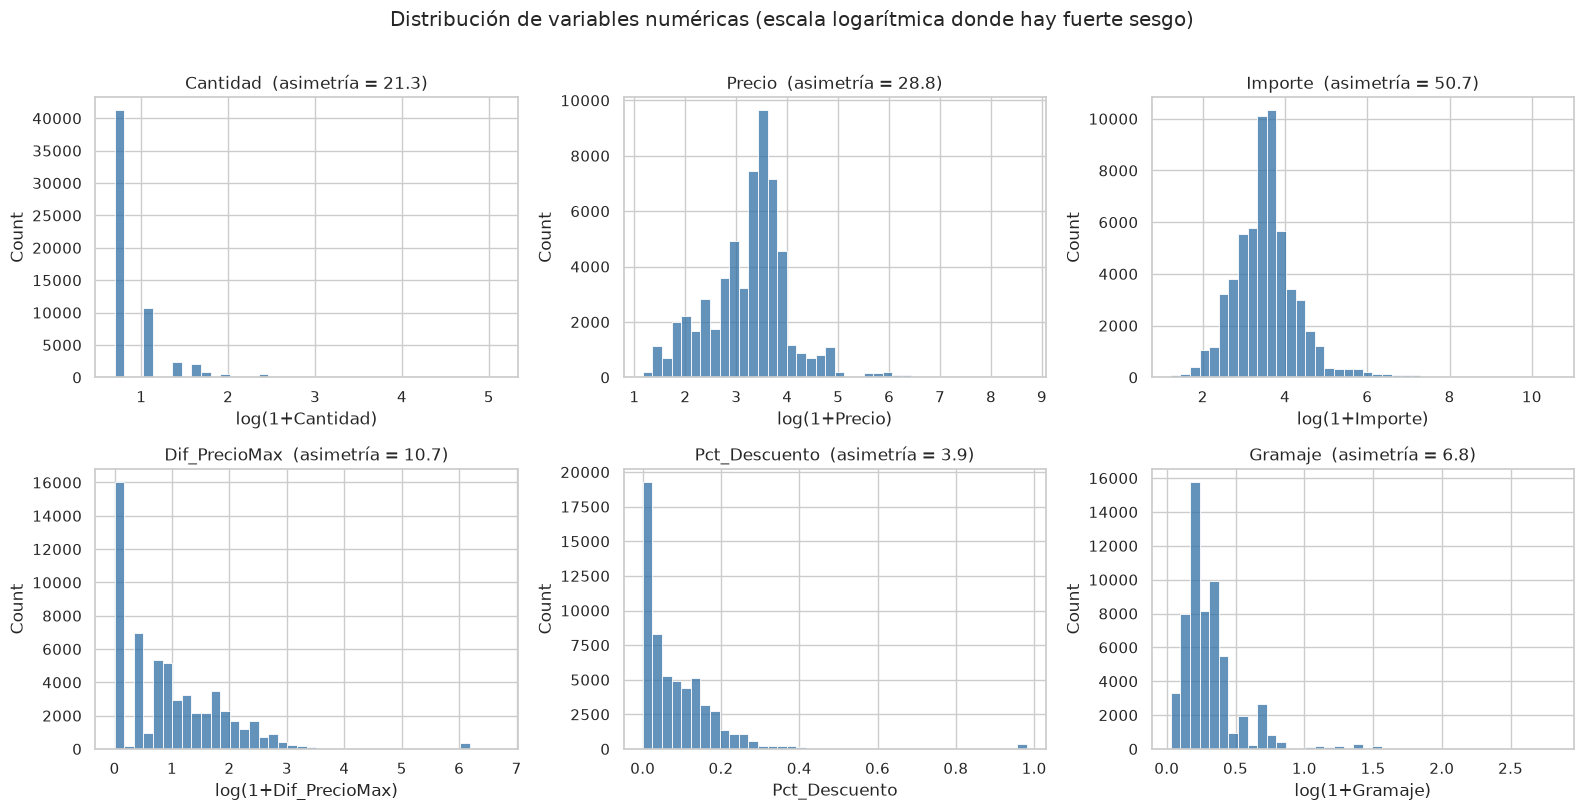

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, ["Cantidad", "Precio", "Importe", "Dif_PrecioMax", "Pct_Descuento", "Gramaje"]):
    x = df[c]
    if c in ["Cantidad", "Precio", "Importe", "Dif_PrecioMax", "Gramaje"]:
        sns.histplot(np.log1p(x), bins=40, ax=ax, color="#2f6fa5"); ax.set_xlabel(f"log(1+{c})")
    else:
        sns.histplot(x, bins=40, ax=ax, color="#2f6fa5"); ax.set_xlabel(c)
    ax.set_title(f"{c}  (asimetría = {x.skew():.1f})")
plt.suptitle("Distribución de variables numéricas (escala logarítmica donde hay fuerte sesgo)", y=1.01)
plt.tight_layout(); plt.show()

### 3.2 Valores atípicos (regla del rango intercuartílico)

In [8]:
def iqr_out(s):
    q1, q3 = s.quantile([.25, .75]); lim = q3 + 1.5*(q3-q1)
    return pd.Series({"Q3+1.5*IQR": lim, "n_atipicos": (s > lim).sum(), "% atipicos": (s > lim).mean()*100, "maximo": s.max()})
display(df[["Cantidad", "Precio", "Importe"]].apply(iqr_out).T.round(2))

print("\nTop 5 importes de línea:")
display(df.nlargest(5, "Importe")[["Fecha", "Descripcion", "Cantidad", "Precio", "Importe"]])

,Q3+1.5*IQR,n_atipicos,% atipicos,maximo
Cantidad,3.50,4613.0,7.83,165.0
Precio,71.75,3975.0,6.75,6000.0
Importe,90.00,5115.0,8.68,38500.0



Top 5 importes de línea:


,Fecha,Descripcion,Cantidad,Precio,Importe
13690,2016-12-01,JAMON IBERICO CAMPOFRIO,11,3500.0,38500.0
13710,2016-12-02,JAMON IBERICO DE BELLOTA,5,6000.0,30000.0
13699,2015-11-30,JAMON IBERICO DE BELLOTA,5,5200.0,26000.0
13691,2016-12-02,JAMON IBERICO CAMPOFRIO,7,3500.0,24500.0
32164,2016-12-05,QUESO MANCHEGO EXTRAMADURADO NBN,165,120.0,19800.0


### 3.3 Ventas en el tiempo

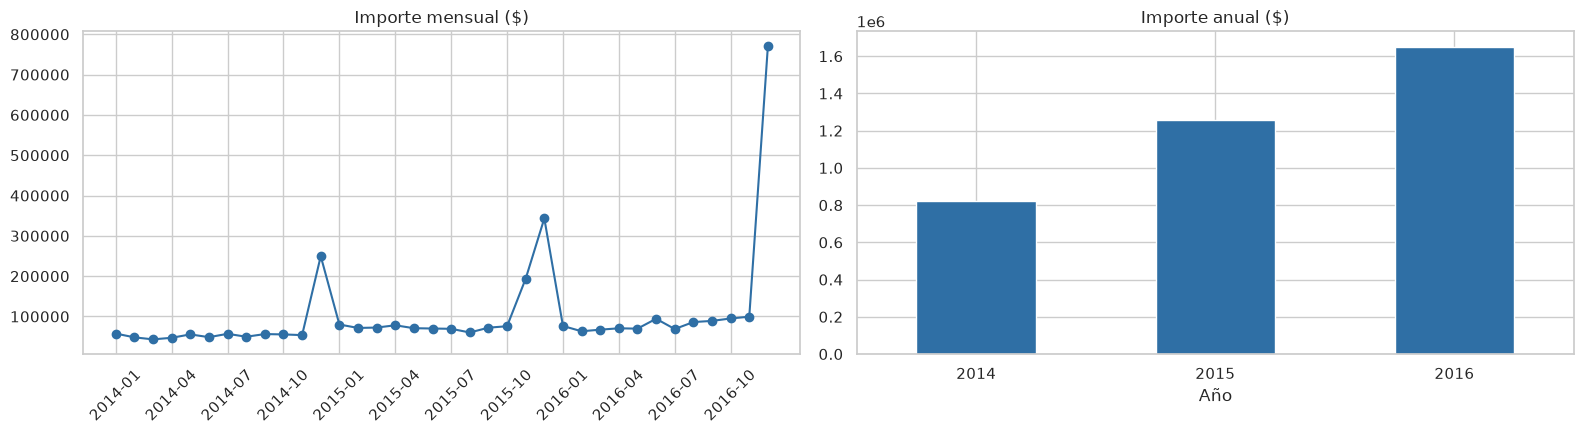

,Importe,Transacciones,Clientes
Año,,,
2014,821850.0,3230,248
2015,1257641.0,3868,323
2016,1650996.0,4246,454


In [9]:
vm = df.groupby("Año_Mes").agg(Importe=("Importe", "sum"), Transacciones=("Transaccion", "nunique"))
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
vm["Importe"].plot(ax=ax[0], marker="o", color="#2f6fa5"); ax[0].set_title("Importe mensual ($)"); ax[0].set_xlabel("")
ax[0].set_xticks(range(0, len(vm), 3)); ax[0].set_xticklabels(vm.index[::3], rotation=45)
va = df.groupby("Año").agg(Importe=("Importe", "sum"), Transacciones=("Transaccion", "nunique"),
                           Clientes=("Clave_Cliente", "nunique"))
va["Importe"].plot(kind="bar", ax=ax[1], color="#2f6fa5"); ax[1].set_title("Importe anual ($)"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
display(va.assign(Importe=va.Importe.round(0)))

### 3.4 Mezcla de producto

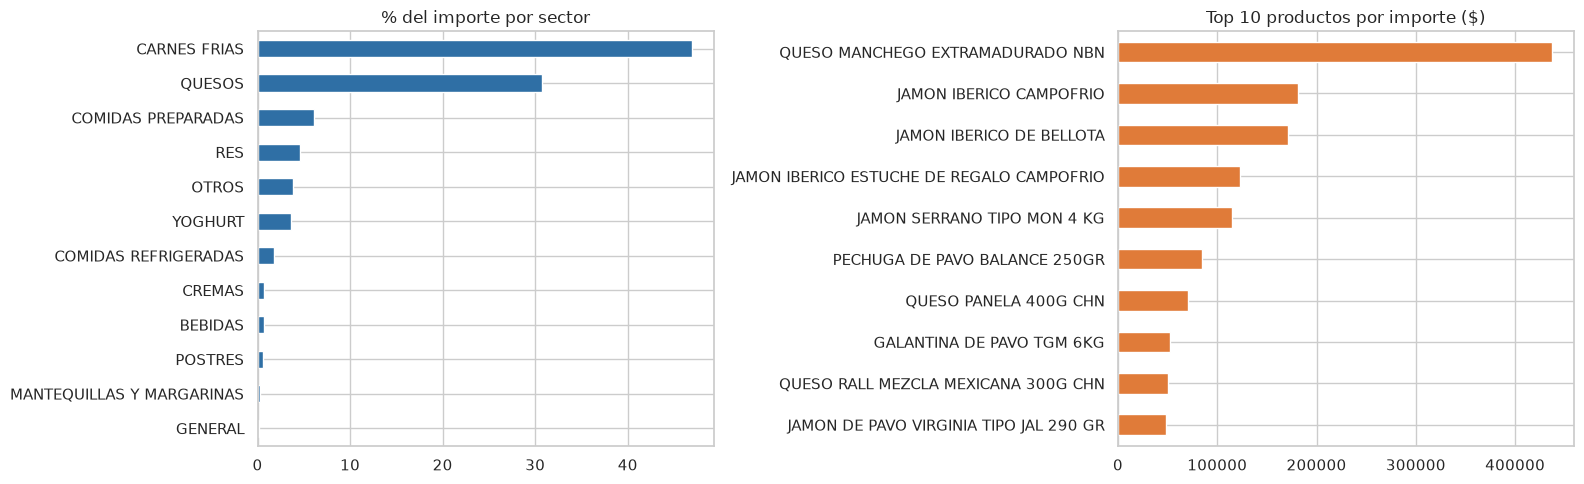

,Importe,Lineas,Clientes,% Importe,% Acumulado
Sector,,,,,
CARNES FRIAS,1750547.4,20807,492,46.9,46.9
QUESOS,1145855.7,17242,459,30.7,77.6
COMIDAS PREPARADAS,228222.5,3677,314,6.1,83.8
RES,170696.5,1679,221,4.6,88.3
OTROS,141101.5,2010,279,3.8,92.1
YOGHURT,134743.8,7094,304,3.6,95.7
COMIDAS REFRIGERADAS,66904.5,1628,210,1.8,97.5
CREMAS,27502.0,2116,250,0.7,98.3
BEBIDAS,27173.0,904,106,0.7,99.0


In [10]:
sec = df.groupby("Sector").agg(Importe=("Importe", "sum"), Lineas=("Importe", "size"),
                               Clientes=("Clave_Cliente", "nunique")).sort_values("Importe", ascending=False)
sec["% Importe"] = sec["Importe"] / sec["Importe"].sum() * 100
sec["% Acumulado"] = sec["% Importe"].cumsum()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sec["% Importe"].sort_values().plot(kind="barh", ax=ax[0], color="#2f6fa5"); ax[0].set_title("% del importe por sector"); ax[0].set_ylabel("")
top = df.groupby("Descripcion")["Importe"].sum().nlargest(10).sort_values()
top.plot(kind="barh", ax=ax[1], color="#e07b39"); ax[1].set_title("Top 10 productos por importe ($)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()
display(sec.round(1))

### 3.5 Estadística descriptiva – nivel cliente (base del clustering)

In [11]:
desc_c = cli[num_modelo].describe(percentiles=[.25, .5, .75, .95]).T
desc_c["asimetria"] = cli[num_modelo].skew()
display(desc_c.round(2))

,count,mean,std,min,25%,50%,75%,95%,max,asimetria
Recencia_dias,524.0,115.93,198.19,0.00,11.00,19.00,115.25,485.70,1073.00,2.39
Frecuencia,524.0,21.65,31.39,1.00,2.00,8.00,28.25,85.70,207.00,2.56
Monto_Total,524.0,7119.25,12392.65,36.00,869.00,2708.00,8707.62,28243.86,161303.15,5.58
Ticket_Promedio,524.0,550.96,2065.17,36.00,181.58,279.11,455.69,1322.50,44500.00,18.84
Lineas_x_Transaccion,524.0,4.33,2.97,1.00,2.08,3.74,5.67,9.76,26.00,1.77
Cantidad_Total,524.0,189.71,355.63,1.00,14.00,54.00,190.00,819.60,3101.00,4.17
Pct_Descuento_Prom,524.0,0.15,0.20,0.00,0.02,0.08,0.18,0.63,0.95,1.98
Precio_Promedio,524.0,127.46,342.93,9.56,30.36,41.16,92.75,430.75,4750.00,10.22
Num_Sectores,524.0,5.71,3.24,1.00,3.00,6.00,8.00,11.00,12.00,0.12
Meses_Activos,524.0,10.11,10.61,1.00,2.00,6.00,16.00,35.00,36.00,1.19


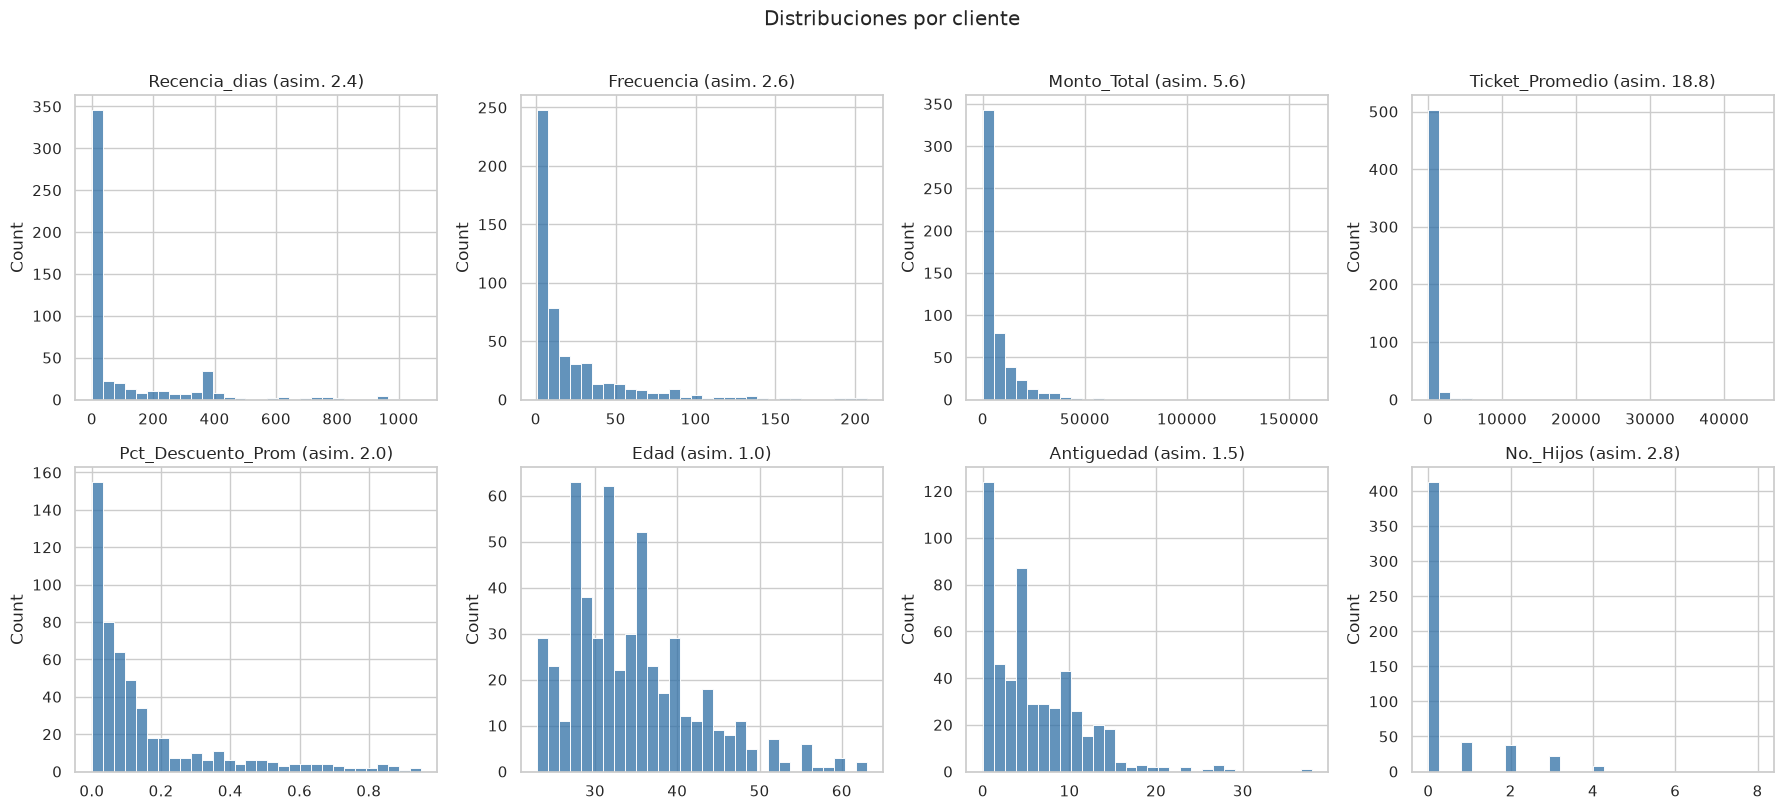

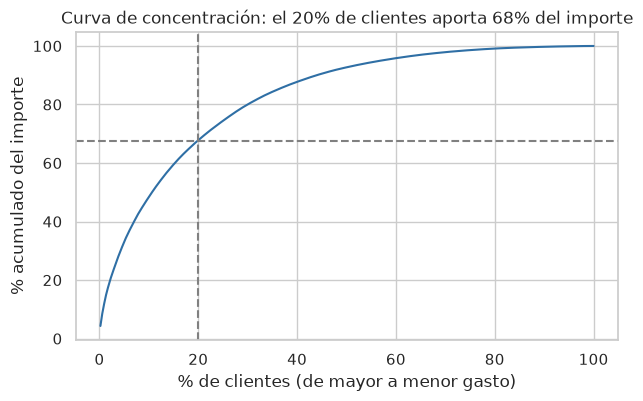

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, ["Recencia_dias", "Frecuencia", "Monto_Total", "Ticket_Promedio",
                             "Pct_Descuento_Prom", "Edad", "Antiguedad", "No._Hijos"]):
    sns.histplot(cli[c], bins=30, ax=ax, color="#2f6fa5"); ax.set_title(f"{c} (asim. {cli[c].skew():.1f})"); ax.set_xlabel("")
plt.suptitle("Distribuciones por cliente", y=1.01); plt.tight_layout(); plt.show()

# Concentración de ventas (Pareto)
m = cli["Monto_Total"].sort_values(ascending=False).reset_index(drop=True)
acum = m.cumsum() / m.sum() * 100
top20 = acum.iloc[int(len(m)*0.2) - 1]
plt.figure(figsize=(7, 4)); plt.plot(np.arange(1, len(m)+1)/len(m)*100, acum, color="#2f6fa5")
plt.axvline(20, ls="--", c="gray"); plt.axhline(top20, ls="--", c="gray")
plt.xlabel("% de clientes (de mayor a menor gasto)"); plt.ylabel("% acumulado del importe")
plt.title(f"Curva de concentración: el 20% de clientes aporta {top20:.0f}% del importe"); plt.show()

### 3.6 Perfil demográfico de los clientes

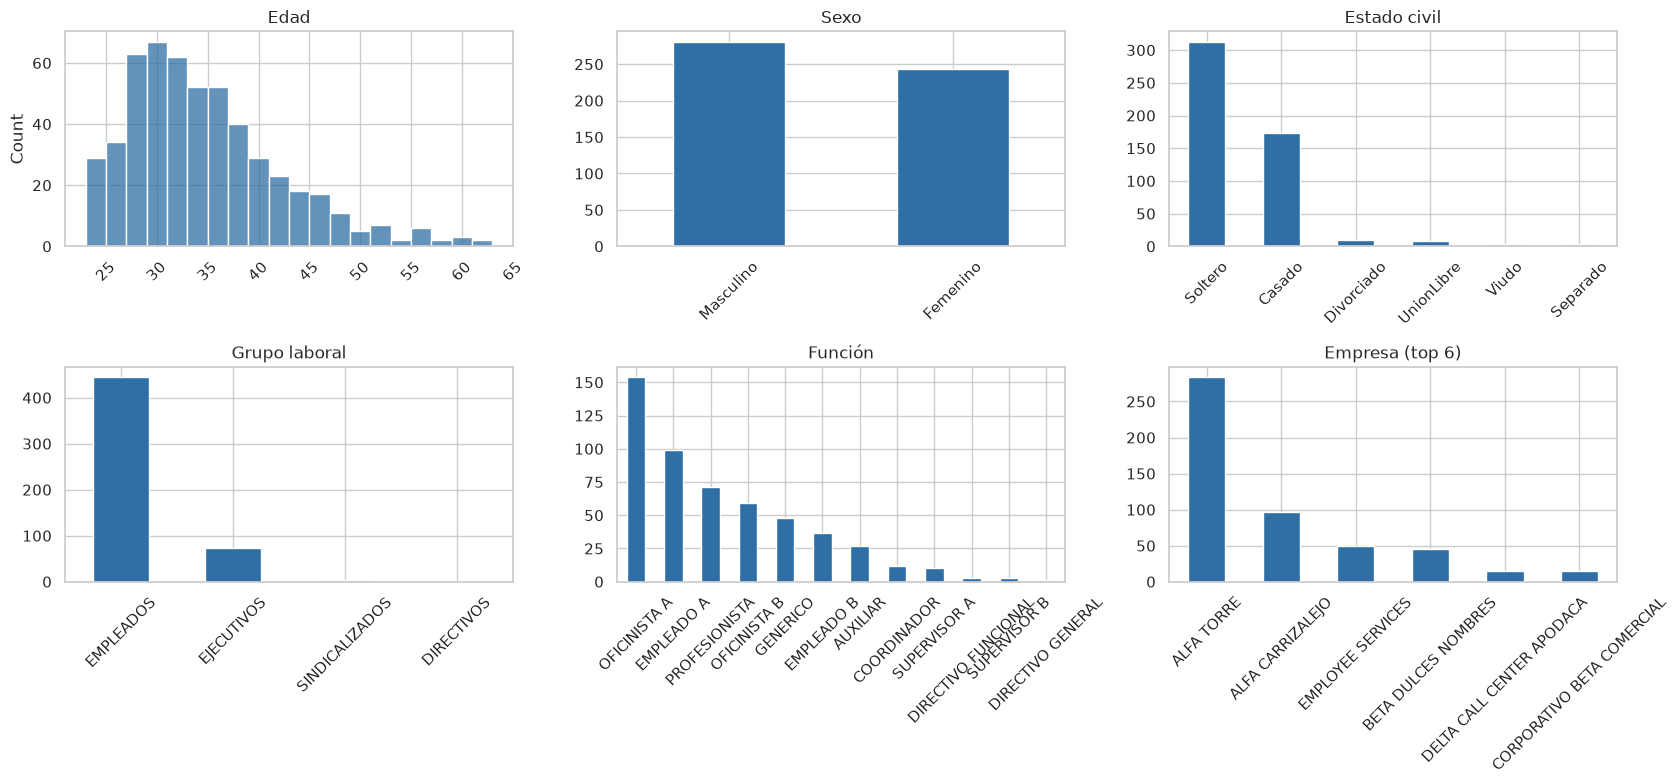

Clientes por estado (%):
Estado
Nuevo Leon          90.8
Coahuila             1.9
Estado de Mexico     1.5
Jalisco              1.1
Durango              0.8
Name: proportion, dtype: float64


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
sns.histplot(cli["Edad"], bins=20, ax=axes[0, 0], color="#2f6fa5"); axes[0, 0].set_title("Edad")
cli["Sexo"].value_counts().plot(kind="bar", ax=axes[0, 1], color="#2f6fa5"); axes[0, 1].set_title("Sexo")
cli["Estado_Civil"].value_counts().plot(kind="bar", ax=axes[0, 2], color="#2f6fa5"); axes[0, 2].set_title("Estado civil")
cli["Grupo"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#2f6fa5"); axes[1, 0].set_title("Grupo laboral")
cli["Funcion"].value_counts().plot(kind="bar", ax=axes[1, 1], color="#2f6fa5"); axes[1, 1].set_title("Función")
cli["Empresa_Nombre"].value_counts().head(6).plot(kind="bar", ax=axes[1, 2], color="#2f6fa5"); axes[1, 2].set_title("Empresa (top 6)")
for a in axes.flat: a.set_xlabel(""); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print("Clientes por estado (%):"); print((cli["Estado"].value_counts(normalize=True)*100).round(1).head(5))

### 3.7 Relaciones entre variables

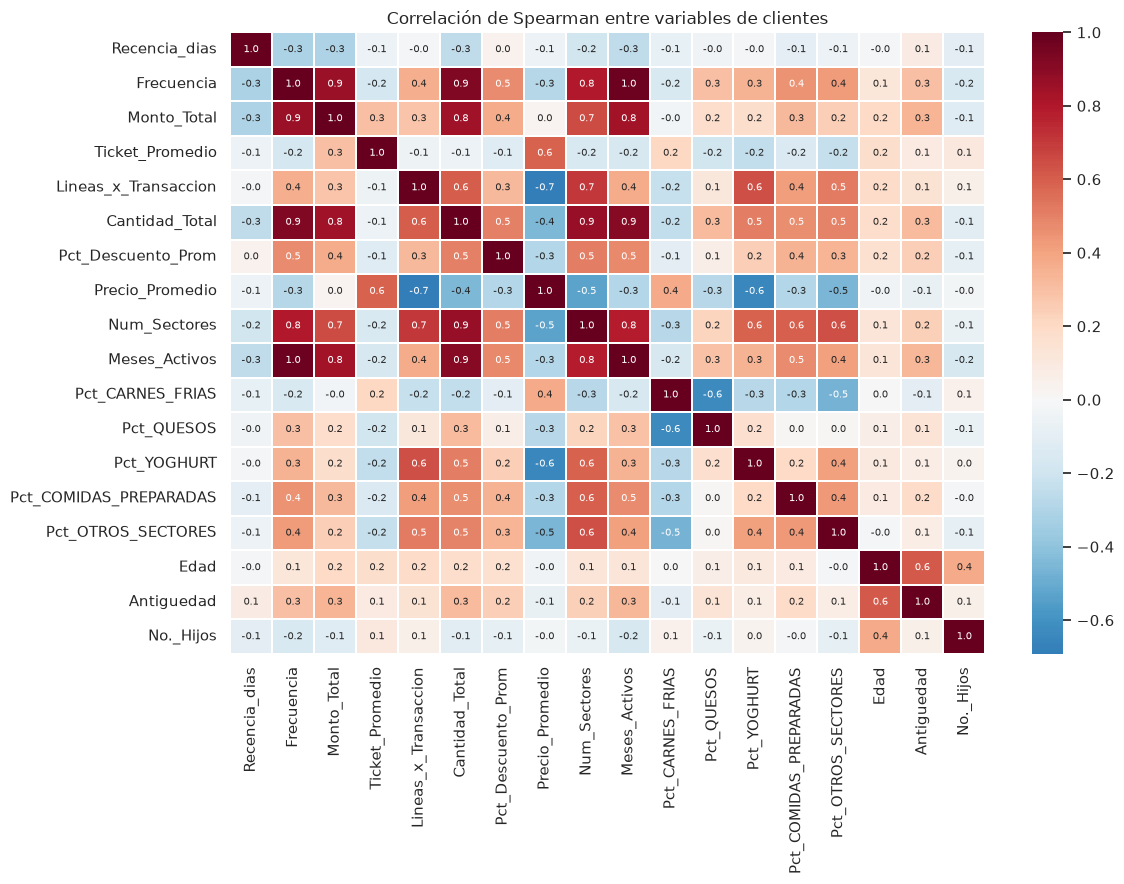

Pares con |correlación| >= 0.8 (posible redundancia):


spearman
Frecuencia     Meses_Activos       0.98
               Cantidad_Total      0.93
Cantidad_Total Meses_Activos       0.91
               Num_Sectores        0.87
Frecuencia     Monto_Total         0.86
Monto_Total    Cantidad_Total      0.85
               Meses_Activos       0.84
Frecuencia     Num_Sectores        0.80

In [14]:
corr = cli[num_modelo].corr(method="spearman")
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".1f", annot_kws={"size": 7}, linewidths=.3)
plt.title("Correlación de Spearman entre variables de clientes"); plt.tight_layout(); plt.show()

pares = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("Pares con |correlación| >= 0.8 (posible redundancia):")
display(pares[pares.abs() >= 0.8].sort_values(ascending=False).round(2).to_frame("spearman"))

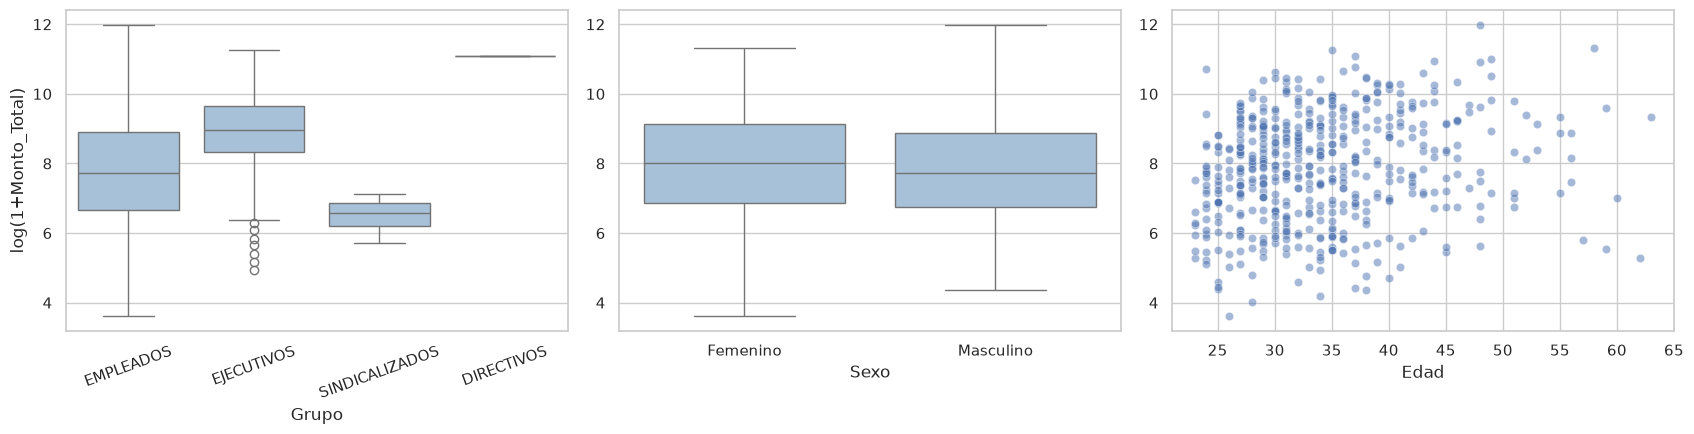

,Frecuencia,Monto_Total,Ticket_Promedio,Pct_Descuento_Prom
Grupo,,,,
DIRECTIVOS,55.0,65626.77,1193.21,0.12
EJECUTIVOS,14.0,7900.56,453.28,0.09
EMPLEADOS,8.0,2278.00,255.69,0.07
SINDICALIZADOS,2.5,728.00,270.52,0.06


In [15]:
# Comparación de gasto por grupo demográfico
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.boxplot(data=cli, x="Grupo", y=np.log1p(cli["Monto_Total"]), ax=ax[0], color="#9ec1e0"); ax[0].set_ylabel("log(1+Monto_Total)")
sns.boxplot(data=cli, x="Sexo", y=np.log1p(cli["Monto_Total"]), ax=ax[1], color="#9ec1e0"); ax[1].set_ylabel("")
sns.scatterplot(data=cli, x="Edad", y=np.log1p(cli["Monto_Total"]), alpha=.5, ax=ax[2]); ax[2].set_ylabel("")
for a in ax[:1]: a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
display(cli.groupby("Grupo")[["Frecuencia", "Monto_Total", "Ticket_Promedio", "Pct_Descuento_Prom"]].median().round(2))

### 3.8 Hallazgos principales
1. **Crecimiento:** el importe pasó de $0.82 M (2014) a $1.26 M (2015) y $1.65 M (2016), con 248, 323 y 454 clientes activos por año. El aumento viene sobre todo de más clientes, no solo de más compras por cliente. Total: $3.73 M en 11,344 transacciones.
2. **Concentración de producto:** Carnes frías (46.9%) y Quesos (30.7%) suman 77.6% del importe. Yoghurt tiene muchas líneas (7,094) pero solo 3.6% del importe.
3. **Distribuciones muy sesgadas:** `Importe` (asimetría 50.7), `Precio` (28.8) y `Cantidad` (21.3) tienen colas largas. A nivel cliente, `Monto_Total` (5.6) y `Ticket_Promedio` (18.8) también. Hay que aplicar `log1p` y estandarizar antes de usar K-Means, DBSCAN o PCA.
4. **Atípicos plausibles:** los mayores importes son jamón ibérico ($6,000 por pieza, línea de hasta $38,500) y una compra de 165 piezas de queso manchego. No son errores, pero pueden aparecer como grupos pequeños o como ruido en DBSCAN.
5. **Concentración de clientes:** el 10% de clientes aporta 48% del importe y el 20% aporta 68%. La mitad de clientes con menor gasto aporta solo 7%.
6. **Clientes muy distintos entre sí:** la mediana de frecuencia es 8 transacciones (rango de 1 a 207) y la de gasto es $2,708 (rango de $36 a $161,303). Una cuarta parte (25%) compró 2 veces o menos. El 65% compró en los últimos 30 días del periodo y 13% lleva más de un año sin comprar. Esta variedad sugiere que existen segmentos naturales.
7. **Descuento:** 27% de las líneas no tienen descuento; la mediana por cliente es 8% y algunos clientes llegan a 63% o más.
8. **Redundancia entre variables:** `Frecuencia`, `Meses_Activos`, `Cantidad_Total`, `Monto_Total` y `Num_Sectores` tienen correlaciones de Spearman entre 0.80 y 0.98. Conviene reducirlas con PCA (punto 6) o elegir un subconjunto, para que no dominen la distancia.
9. **Perfil demográfico:** 54% hombres, 61% solteros, edad mediana de 33 años y 91% de los clientes en Nuevo León. El 85% pertenece al grupo `EMPLEADOS`. Las demás categorías son pequeñas (74 ejecutivos, 4 sindicalizados y **1 directivo**), por lo que la comparación por `Grupo` es poco confiable y la diferencia de gasto que se ve (directivos con mediana de $65,627) corresponde a un solo cliente.
10. **Variables débiles para segmentar:** `Escolaridad` (86% sin dato), `Estado` (casi todo Nuevo León) y `Grupo` (desbalanceada). Se recomienda usarlas solo para describir los clusters, no para formarlos.

## 4. Desarrollo de los modelos de agrupación

En esta sección se implementan y comparan tres familias distintas de algoritmos no supervisados sobre la base de clientes consolidada (`clientes_features.csv`, $N = 524$ clientes):

1. **K-Means:** Algoritmo particional basado en centroides y optimización de varianza intra-cluster.
2. **DBSCAN:** Algoritmo basado en densidad espacial, capaz de descubrir agrupaciones de forma arbitraria y aislar valores atípicos (ruido).
3. **Agrupación Jerárquica Aglomerativa (Ward):** Algoritmo ascendente que construye una jerarquía de distancias y permite inspeccionar la estructura de subgrupos mediante un dendrograma.

Adicionalmente, se aplica **Análisis de Componentes Principales (PCA)** para la reducción dimensional y proyección gráfica en 2D, y se evalúa el rendimiento mediante **Inercia**, **Coeficiente de Silhouette** e **Índice de Davies-Bouldin**.

### 4.1 Preprocesamiento y estandarización del espacio de características

Las variables de volumen y valor monetario (`Monto_Total`, `Frecuencia`, `Ticket_Promedio`, `Cantidad_Total`, `Precio_Promedio` y `Recencia_dias`) presentan asimetría positiva severa y colas largas. Para evitar que magnitudes dispares y compras excepcionales dominen artificialmente las distancias euclidianas, se aplica la transformación suavizada $\ln(1 + x)$ (`np.log1p`) y posteriormente se estandarizan todas las variables numéricas a media cero y varianza unitaria ($\mu = 0, \sigma^2 = 1$) mediante `StandardScaler`.

In [16]:
import pandas as pd

df = pd.read_csv('clientes_features.csv')

df.head()

,Clave_Cliente,Frecuencia,Monto_Total,Ticket_Promedio,Lineas_x_Transaccion,Recencia_dias,Cantidad_Total,Precio_Promedio,Pct_Descuento_Prom,Num_Sectores,Meses_Activos,Pct_CARNES_FRIAS,Pct_COMIDAS_PREPARADAS,Pct_OTROS_SECTORES,Pct_QUESOS,Pct_YOGHURT,Edad,Antiguedad,No._Hijos,Sexo,Estado_Civil,Grupo,Funcion,Estado,Empresa_Nombre
0,100167,45,6791.96,150.932444,2.711111,38,250,43.146475,0.456949,10,19,0.323930,0.061072,0.309342,0.296159,0.009497,35,15,0,Femenino,Soltero,EMPLEADOS,GENERICO,Nuevo Leon,ALFA CARRIZALEJO
1,100263,40,6951.88,173.797000,5.475000,64,250,30.553333,0.086709,7,29,0.395807,0.002517,0.055050,0.362578,0.184048,40,15,0,Masculino,Soltero,EMPLEADOS,OFICINISTA A,Nuevo Leon,ALFA TORRE
2,100363,2,373.50,186.750000,5.500000,22,14,26.909091,0.000000,3,1,0.388220,0.171352,0.000000,0.440428,0.000000,35,15,2,Masculino,Casado,EMPLEADOS,GENERICO,Nuevo Leon,CAMPUS DELTA SANTA CATARINA
3,100491,2,328.00,164.000000,3.500000,22,8,38.357143,0.000000,2,1,0.891768,0.000000,0.000000,0.108232,0.000000,57,15,0,Femenino,Soltero,EMPLEADOS,AUXILIAR,San Luis Potosi,DELTA CALL CENTER APODACA
4,100861,49,12792.41,261.069592,5.714286,201,414,33.742179,0.192171,9,23,0.537693,0.099614,0.087865,0.241113,0.033715,41,15,0,Femenino,Soltero,EMPLEADOS,EMPLEADO A,Nuevo Leon,ALFA TORRE


In [17]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#Estabilizar con np.log1p()

cols_log1p = [
    "Frecuencia",
    "Monto_Total",
    "Recencia_dias",
    "Cantidad_Total",
    "Precio_Promedio"
]

df_log = df.copy()

for col in cols_log1p:
    df_log[col] = np.log1p(df_log[col])

#Normalizar con StandardScaler()

cols_scaler = [
    "Frecuencia",
    "Monto_Total",
    "Ticket_Promedio",
    "Lineas_x_Transaccion",
    "Recencia_dias",
    "Cantidad_Total",
    "Precio_Promedio",
    "Pct_Descuento_Prom",
    "Num_Sectores",	
    "Meses_Activos",
    "Pct_CARNES_FRIAS",
    "Pct_QUESOS",
    "Pct_YOGHURT",
    "Pct_COMIDAS_PREPARADAS",
    "Pct_OTROS_SECTORES",
    "Edad",
    "Antiguedad",
    "No._Hijos"
]

scaler = StandardScaler().set_output(transform="pandas")
df_scaled = scaler.fit_transform(df_log[cols_scaler])

### 4.2 Modelo 1: K-Means

#### 4.2.1 Determinación del número óptimo de clusters ($k$) (método del codo)
Se evalúa el espacio de soluciones para $k \in [2, 10]$ utilizando un criterio complementarios:
* **Inercia (WCSS):** Mide la cohesión interna (suma de distancias cuadráticas de cada cliente a su centroide). Se busca el punto de inflexión o "codo".


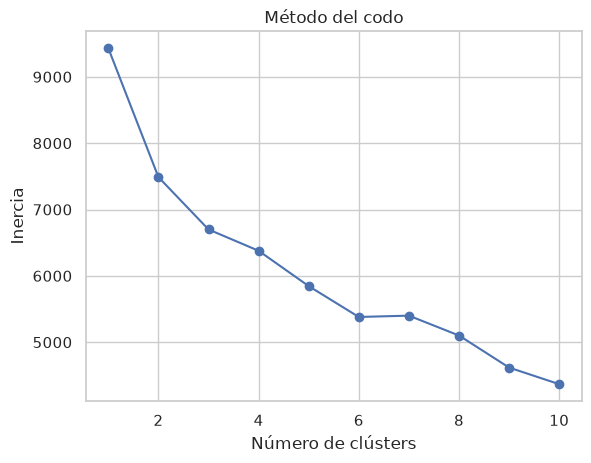

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)

plt.plot(range(1,11), inercias, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.show()

#### Interpretación de la selección de $k$
* **Comportamiento del Codo:** La curva de inercia desciende de manera pronunciada entre $k=2$ y $k=4$, comenzando a estabilizar su tasa de reducción a partir de $k=5$.

#### 4.2.2 Ejecución del modelo 

In [19]:

N_CLUSTERS = 5

kmeans = KMeans(n_clusters=N_CLUSTERS,random_state=42, n_init=10)
df['KMeans'] = kmeans.fit_predict(df_scaled)

#### 4.2.3 Reducción dimensional con PCA e interpretación de componentes

Debido a que el modelo opera en un espacio de 18 dimensiones, se emplea Análisis de Componentes Principales (PCA) como técnica de proyección lineal para inspeccionar la geometría de los clusters en 2D sin alterar las distancias calculadas durante el entrenamiento.

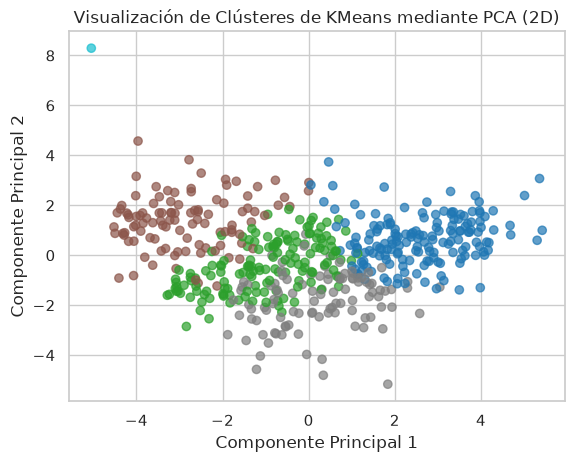

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2,random_state=42)
df_2d = pca.fit_transform(df_scaled)

plt.scatter(df_2d[:, 0], df_2d[:, 1], c=df['KMeans'], cmap='tab10', alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de Clústeres de KMeans mediante PCA (2D)")
plt.show()

#### Interpretación de los Componentes Principales
* **PCA 1 (Magnitud y recurrencia de compra / Dimensión RFM):** Presenta cargas positivas dominantes en `Frecuencia`, `Monto_Total`, `Cantidad_Total`, `Meses_Activos` y `Num_Sectores`, contrastando con una carga negativa en `Recencia_dias`. Los clientes situados a la derecha del plano ($PCA1 > 0$) representan a los compradores leales, multicanal y de alto valor acumulado, mientras que la izquierda reúne a los clientes esporádicos o inactivos.
* **PCA 2 (Contraste de categoría y estilo de canasta):** Está gobernado por la composición del gasto en productos. Muestra una fuerte correlación positiva con `Pct_CARNES_FRIAS` y `Precio_Promedio`, contra pesos negativos en `Pct_QUESOS` y `Pct_YOGHURT`. Clientes con valores altos de $PCA2$ concentran su presupuesto en embutidos y carnes de mayor valor unitario, mientras que valores negativos corresponden a compradores centrados en lácteos y quesos.

### 4.2.4 Validación de rendimiento del modelo

* **Validación con Silhouette y Davies-Bouldin:** El valor de $k=5$ ofrece una solución balanceada: mantiene un coeficiente de Silhouette competitivo, reduce el índice de Davies-Bouldin respecto a particiones menores y genera una granularidad comercial manejable y accionable para la empresa de alimentos (evitando la fragmentación excesiva de clusters con muy pocos clientes que ocurre cuando $k \ge 8$).

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertia = kmeans.inertia_
silhouette = silhouette_score(df_scaled, df['KMeans'])
davies_bouldin = davies_bouldin_score(df_scaled, df['KMeans'])

print(f"Número de clústers (k): {N_CLUSTERS}")
print(f"Inercia (WCSS): {inertia:.2f}")
print(f"Silhouette score: {silhouette:.4f}")
print(f"Davies-Bouldin score: {davies_bouldin:.4f}")

Número de clústers (k): 5
Inercia (WCSS): 5781.91
Silhouette score: 0.1663
Davies-Bouldin score: 1.7633


Para determinar de manera objetiva el número óptimo de grupos ($k$) sobre los 524 clientes analizados, se emplean tres métricas complementarias de validación interna:

1. **Inercia (Within-Cluster Sum of Squares - WCSS):**
   * **Definición:** Corresponde a la suma de las distancias euclidianas al cuadrado de cada cliente con respecto al centroide de su clúster asignado ($\sum_{j=1}^{k} \sum_{x \in C_j} ||x - \mu_j||^2$).
   * **Interpretación:** Evalúa la **cohesión o compacidad intra-clúster**. Un valor menor indica que los clientes dentro de un mismo segmento son muy homogéneos en su comportamiento de compra y perfil demográfico[cite: 1].
   * **Criterio de decisión:** La inercia disminuye de forma monótona conforme se incrementa $k$ (llegando a cero si $k=n$). Por lo tanto, se aplica el **método del codo (*Elbow Method*)**, identificando el punto de inflexión en el que la reducción marginal de la inercia deja de ser pronunciada, señalando un balance eficiente entre complejidad y homogeneidad.

2. **Coeficiente de Silueta (*Silhouette Score*):**
   * **Definición:** Mide qué tan similar es un cliente a los miembros de su propio clúster (cohesión $a$) en comparación con el clúster vecino más cercano (separación $b$), calculándose como $s = \frac{b - a}{\max(a, b)}$.
   * **Interpretación:** Toma valores en el intervalo $[-1, 1]$:
     * **Cercano a $+1$:** El cliente está asignado de forma óptima; se encuentra muy compacto dentro de su grupo y bien distanciado de otros segmentos.
     * **Cercano a $0$:** El cliente se ubica en la frontera de decisión entre dos grupos, indicando solapamiento.
     * **Valores negativos:** Indican que la observación probablemente fue clasificada en el clúster incorrecto.
   * **Criterio de decisión:** Se selecciona el valor de $k$ que maximice el promedio global del coeficiente de silueta.

3. **Índice de Davies-Bouldin (DBI):**
   * **Definición:** Cuantifica la similitud promedio entre cada clúster y su vecino más parecido, calculando el cociente entre la suma de sus dispersiones internas y la distancia euclidiana entre sus respectivos centroides.
   * **Interpretación:** Evalúa simultáneamente la dispersión interna y la separación inter-clúster. A diferencia del Silhouette Score, **valores menores indican un mejor agrupamiento**, pues reflejan grupos densos y ampliamente separados entre sí.
   * **Criterio de decisión:** Se busca el valor de $k$ donde el índice alcance su mínimo local.

### 4.3 Modelo 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Justificación:** A diferencia de K-Means, DBSCAN no impone particiones esféricas ni presupone un número fijo de grupos; agrupa observaciones en función de la densidad de vecinos en un radio $\varepsilon$ (`eps`) y etiqueta como **ruido ($-1$)** a aquellas observaciones aisladas en regiones de baja densidad. Esto es de alto valor en ventas retail para detectar compras anómalas o clientes con patrones de consumo atípicos.


### 4.3.1 Algoritmo de optimización (Estimación de hiperparámetros)
Se fija `min_samples = 5` y se calcula la curva de distancias ordenadas al 5.º vecino más cercano (*k-distance graph*) para identificar la distancia crítica donde la pendiente sufre una inflexión abrupta.

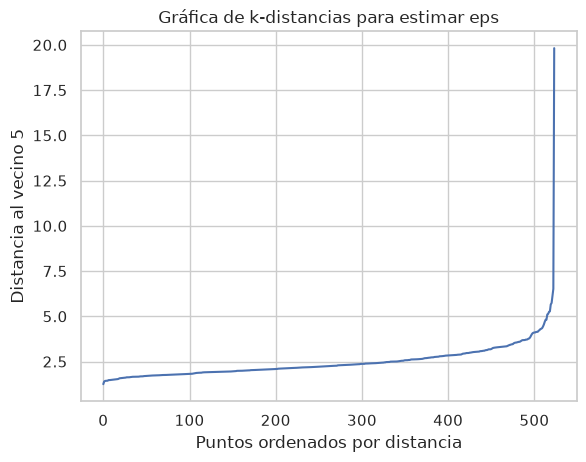

In [22]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = 5 # Regla general: min_samples >= dimensiones + 1, o ajustar según el tamaño del dataset
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)

distances = np.sort(distances[:, min_samples-1], axis=0)
plt.plot(distances)
plt.title('Gráfica de k-distancias para estimar eps')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al vecino {min_samples}')
plt.grid(True)
plt.show()

El algoritmo DBSCAN requiere la calibración de dos hiperparámetros fundamentales: `min_samples` ($k$) y la distancia máxima de vecindad `eps` ($\varepsilon$). La gráfica de $k$-distancias (*k-NN distance graph*) es la herramienta analítica estándar para seleccionar un $\varepsilon$ adecuado:

* **Construcción:** Para cada uno de los 524 clientes[cite: 1], se calcula la distancia euclidiana hacia su $k$-ésimo vecino más próximo (donde $k$ usualmente se iguala a `min_samples`). Posteriormente, todas estas distancias se ordenan de forma ascendente y se representan en una curva continua.
* **Significado de la curva:**
  * **Zona inferior / plana:** Representa a los clientes que se sitúan en regiones de alta densidad (núcleos de clústeres), donde las distancias entre vecinos son reducidas y estables.
  * **Punto de inflexión o "codo" (*knee point*):** Marca el umbral de transición donde la distancia hacia los vecinos comienza a crecer con rapidez. Este valor en el eje vertical representa el radio $\varepsilon$ óptimo: captura densidades naturales sin sobredimensionar la vecindad.
  * **Pendiente pronunciada final:** Corresponde a observaciones aisladas o periféricas cuyas distancias a los vecinos más cercanos son muy elevadas (candidatos naturales a ruido/atípicos).
* **Impacto en el modelo:** Elegir un $\varepsilon$ por debajo del codo provocará que la mayoría de los clientes sean descartados como ruido; por el contrario, un $\varepsilon$ muy por encima fusionará segmentos de consumo distintos en un único macro-grupo.

### 4.3.2 Ejecución del modelo

In [23]:
from sklearn.cluster import DBSCAN

# Observando la curva de k-distancias, seleccionamos el valor del "codo" para eps.
# Ajusta este valor (EPS_VALUE) dependiendo de dónde veas la inflexión en tu gráfica anterior.
EPS_VALUE = 2.5 # Valor de ejemplo, ajusta según la gráfica

dbscan = DBSCAN(eps=EPS_VALUE, min_samples=min_samples)
df['DBSCAN'] = dbscan.fit_predict(df_scaled)

# Análisis de ruido
n_clusters_ = len(set(df['DBSCAN'])) - (1 if -1 in df['DBSCAN'] else 0)
n_noise_ = list(df['DBSCAN']).count(-1)

print(f"Número estimado de clusters: {n_clusters_}")
print(f"Número estimado de puntos de ruido: {n_noise_}")

Número estimado de clusters: 2
Número estimado de puntos de ruido: 123


A diferencia de K-Means, DBSCAN no impone un número fijo de grupos ni asume esfericidad, sino que descubre agrupaciones basadas en conectividad por densidad:

* **Clústeres estimados:**
  * Representan las densidades continuas de clientes que comparten perfiles y hábitos de consumo similares (combinaciones de recencia, frecuencia, ticket promedio y mezcla de categorías como carnes frías o quesos)[cite: 1].
  * Reflejan la cantidad real de patrones comunes que emergen de la estructura de los datos sin forzar la partición de la muestra.
* **Puntos de ruido (Etiqueta `-1`):**
  * Son aquellos clientes que no alcanzan el umbral de `min_samples` dentro del radio $\varepsilon$ ni son alcanzables desde el núcleo de ningún grupo.
  * **Interpretación de negocio:** En este conjunto de datos, el ruido no debe interpretarse como error de captura, sino como **clientes con comportamientos de compra atípicos o excepcionales**[cite: 1]. Por ejemplo, clientes con compras esporádicas de productos de valor extremadamente alto, clientes con volúmenes de compra masivos o frecuencias singulares que no encajan en el perfil corporativo promedio[cite: 1]. Su aislamiento permite proteger la pureza de los segmentos principales y formular estrategias comerciales personalizadas para ellos.

#### Interpretación de los resultados de DBSCAN
* **Concentración de la densidad:** Al trabajar con 18 dimensiones, el fenómeno de la dispersión multidimensional (*curse of dimensionality*) hace que la mayoría de los puntos se concentren en un macro-cluster denso central o queden aislados como ruido si el radio $\varepsilon$ es muy estricto.
* **Aislamiento de ruido útil:** DBSCAN logra separar efectivamente a los clientes con tickets extremos o compras desproporcionadas (como quienes adquirieron piezas enteras de jamón ibérico o compras institucionales masivas) bajo la etiqueta `-1`, previniendo que sesguen la segmentación de la clientela habitual.

### 4.3.3 Optimización de dimensionalidad de variables con PCA

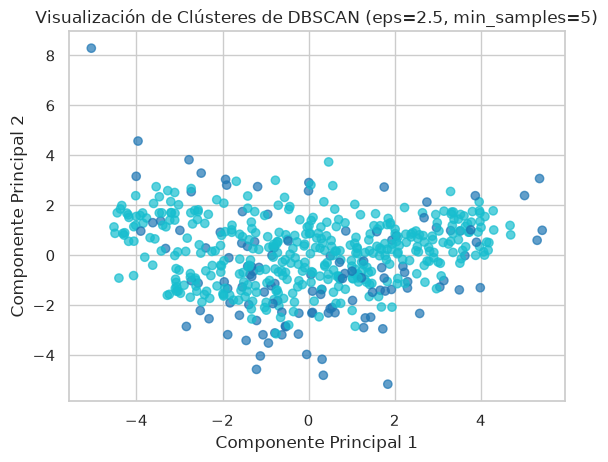

In [24]:
# Visualización con PCA
plt.scatter(df_2d[:, 0], df_2d[:, 1], c=df['DBSCAN'], cmap='tab10', alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(f"Visualización de Clústeres de DBSCAN (eps={EPS_VALUE}, min_samples={min_samples})")
plt.show()

Dado que la segmentación utiliza 18 variables numéricas transformadas y estandarizadas (RFM, montos, mezcla de sectores y demográficas), resulta imposible visualizar los clústeres en su espacio original:

* **Objetivo de PCA:** Se realiza una reducción de dimensionalidad proyectando las 18 variables sobre las dos primeras componentes principales (PC1 y PC2), las cuales concentran el mayor porcentaje de la varianza total de los clientes.
* **Interpretación gráfica:**
  * **Ejes principales:** PC1 y PC2 condensan los factores de mayor variabilidad del comportamiento de compra, como el volumen/gasto acumulado y la concentración de categorías de producto[cite: 1].
  * **Distribución de grupos:** Cada clúster identificado por DBSCAN se representa con un color específico, lo que permite evaluar visualmente si los grupos poseen formas complejas o alargadas que K-Means no podría identificar.
  * **Localización del ruido:** Los puntos clasificados como ruido (marcados comúnmente en gris o con marcadores distintivos) suelen aparecer en los extremos o en zonas de baja densidad del plano factorial, confirmando visualmente su condición de clientes atípicos aislados de las nubes densas de consumo corporativo[cite: 1].

### 4.3.4 Validación de rendimiento del modelo

In [25]:
# Evaluación (Nota: las métricas requieren más de un cluster válido y no ser solo ruido)
if n_clusters_ > 1:
    # Excluimos el ruido (-1) para el cálculo de Silhouette y Davies-Bouldin si es necesario, 
    # o calculamos sobre todos. Aquí calculamos sobre todos para comparar equitativamente.
    silhouette_db = silhouette_score(df_scaled, df['DBSCAN'])
    davies_bouldin_db = davies_bouldin_score(df_scaled, df['DBSCAN'])
    print(f"Silhouette score (DBSCAN): {silhouette_db:.4f}")
    print(f"Davies-Bouldin score (DBSCAN): {davies_bouldin_db:.4f}")
else:
    print("DBSCAN no encontró suficientes clusters para calcular las métricas (solo encontró ruido o un único cluster).")

Silhouette score (DBSCAN): 0.1641
Davies-Bouldin score (DBSCAN): 4.0833


La interpretación de las métricas de calidad en DBSCAN requiere consideraciones metodológicas especiales:

* **Tratamiento del ruido en las métricas:**
  * Los indicadores como el *Silhouette Score* y el índice de *Davies-Bouldin* deben calcularse **excluyendo los puntos etiquetados como ruido (`-1`)**, evaluando únicamente los clústeres genuinos. Si se incluyera el ruido como un grupo regular, las métricas se deteriorarían artificialmente al tratarse de un conjunto disperso y no cohesivo.
* **Evaluación del Silhouette Score:**
  * Un valor positivo y alto indica que las densidades descubiertas son compactas y se encuentran bien diferenciadas entre sí.
  * Sin embargo, un Silhouette Score muy elevado puede ser engañoso si se obtuvo a costa de clasificar a una proporción excesiva de los 524 clientes como ruido[cite: 1]. El resultado óptimo debe balancear un coeficiente de silueta saludable con un porcentaje razonable de cobertura del padrón de clientes.
* **Evaluación del índice de Davies-Bouldin:**
  * Un DBI bajo ratifica que los clústeres densos poseen una dispersión pequeña en comparación con la separación entre sus regiones centrales.
* **Balance global:** La mejor parametrización de $(\varepsilon, \text{min\_samples})$ es aquella que maximiza la calidad de agrupación (alto Silhouette, bajo DBI) manteniendo la utilidad práctica de la segmentación para la empresa (evitando que más del 10%–20% de los clientes queden sin clasificar).

### 4.4 Modelo 3: Agrupación Jerárquica Aglomerativa (Hierarchical Clustering)

**Justificación:** El clustering jerárquico aglomerativo no asume formas preconcebidas y construye una estructura de árbol ascendente. Al utilizar el criterio de **enlace de Ward** (`ward`), se minimiza el incremento de la varianza total intra-cluster en cada paso de fusión, asemejándose al objetivo de K-Means pero permitiendo inspeccionar la proximidad jerárquica de los perfiles antes de decidir el corte.

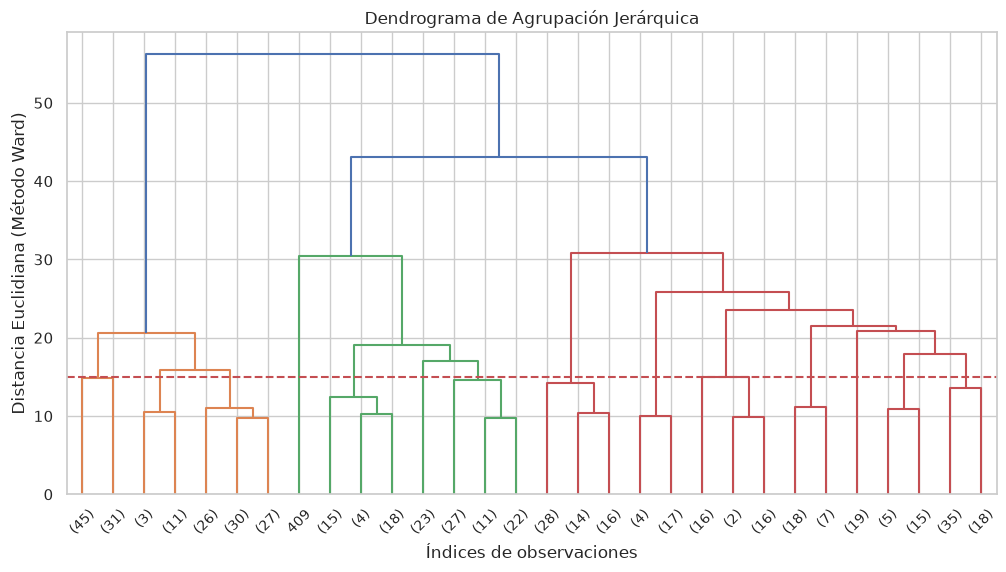

In [26]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 6))
plt.title('Dendrograma de Agrupación Jerárquica')
plt.xlabel('Índices de observaciones')
plt.ylabel('Distancia Euclidiana (Método Ward)')

# Generamos la matriz de enlace utilizando el método de varianza de Ward
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Creamos el dendrograma
dendrogram = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(y=15, color='r', linestyle='--') # Puedes ajustar la línea roja para visualizar el punto de corte
plt.show()

El agrupamiento jerárquico aglomerativo construye una jerarquía de grupos de manera iterativa ascendente, representada visualmente mediante un **dendrograma**:

* **Estructura y lectura del gráfico:**
  * **Eje horizontal:** Representa a los 524 clientes individuales analizados[cite: 1] (o subgrupos en etapas avanzadas). Al inicio, cada cliente constituye su propio clúster.
  * **Eje vertical:** Representa la distancia euclidiana de disimilitud a la cual se unen dos grupos sucesivos mediante el criterio de enlace seleccionado (por ejemplo, método de Ward, enlace completo o promedio).
  * **Altura de las ramas verticales:** La longitud de una línea vertical antes de fusionarse con otra indica qué tan disímiles eran los dos segmentos que se están combinando.
* **Criterio de corte y selección de $k$:**
  * Para determinar el número óptimo de segmentos se traza una línea de corte horizontal transversal.
  * El corte se realiza en la altura donde se observe la mayor distancia vertical sin intersecciones horizontales significativas, lo que evidencia que la unión posterior implicaría forzar grupos sustancialmente diferentes.
  * La cantidad de líneas verticales cortadas por dicha horizontal define el número natural de clústeres ($k$) de clientes corporativos[cite: 1].

### 4.4.1 Ejecución del modelo

In [27]:
from sklearn.cluster import AgglomerativeClustering

# Basándonos en la exploración previa, definimos el número de clusters
N_CLUSTERS_HC = 5 

hc = AgglomerativeClustering(n_clusters=N_CLUSTERS_HC, metric='euclidean', linkage='ward')
df['Jerarquico'] = hc.fit_predict(df_scaled)


### 4.4.2 Optimización de dimensionalidad de variables con PCA

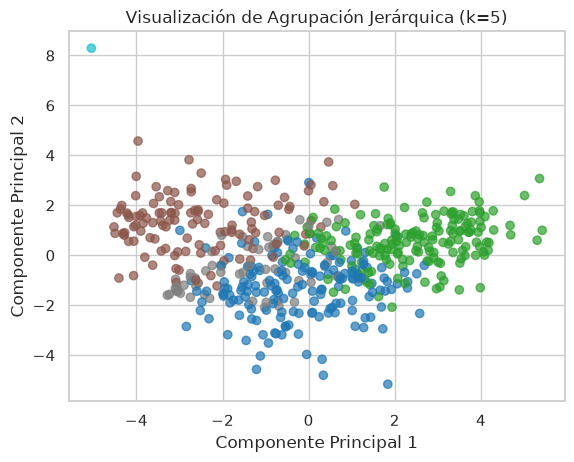

In [28]:

# Visualización con PCA
plt.scatter(df_2d[:, 0], df_2d[:, 1], c=df['Jerarquico'], cmap='tab10', alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title(f"Visualización de Agrupación Jerárquica (k={N_CLUSTERS_HC})")
plt.show()


Tras definir la partición a partir del corte del dendrograma, se proyectan las asignaciones en el plano bidimensional de las dos primeras componentes principales (PC1 y PC2):

* **Evaluación visual de la partición:**
  * Si se utilizó el método de enlace de Ward (*Ward's Linkage*), el algoritmo busca minimizar la varianza intra-clúster en cada paso, produciendo grupos relativamente convexos y balanceados en tamaño.
  * La gráfica permite corroborar si los clústeres jerárquicos ocupan cuadrantes diferenciados del plano factorial (por ejemplo, diferenciando a clientes de alto volumen y gasto frecuente de aquellos con compras esporádicas o preferencias exclusivas en carnes frías o quesos)[cite: 1].
* **Diferencias con otros modelos:**
  * A diferencia de DBSCAN, la totalidad de los 524 clientes queda incorporada dentro de algún grupo de la jerarquía[cite: 1].
  * La proyección en PCA permite diagnosticar si los clientes con comportamientos atípicos fueron absorbidos en los bordes de los clústeres principales o si generaron un subgrupo jerárquico independiente de menor tamaño.

### 4.4.4 Validación de rendimiento del modelo

In [29]:

# Evaluación de métricas
silhouette_hc = silhouette_score(df_scaled, df['Jerarquico'])
davies_bouldin_hc = davies_bouldin_score(df_scaled, df['Jerarquico'])

print(f"Número de clústers (k): {N_CLUSTERS_HC}")
print(f"Silhouette score (Jerárquico): {silhouette_hc:.4f}")
print(f"Davies-Bouldin score (Jerárquico): {davies_bouldin_hc:.4f}")

Número de clústers (k): 5
Silhouette score (Jerárquico): 0.1534
Davies-Bouldin score (Jerárquico): 1.6329


Para corroborar la calidad del agrupamiento jerárquico y comparar su desempeño frente a K-Means y DBSCAN sobre los 524 clientes[cite: 1], se evalúan los indicadores de validación interna:

* **Evaluación del Coeficiente de Silueta (*Silhouette Score*):**
  * Se evalúa el coeficiente promedio para diferentes alturas de corte ($k$) y tipos de enlace (*Ward*, *Complete*, *Average*).
  * Un valor promedio positivo y consistente respalda que los clientes clasificados en un mismo nivel de la jerarquía guardan mayor similitud interna que con clientes de ramas contiguas del árbol.
* **Evaluación del Índice de Davies-Bouldin (DBI):**
  * Se analiza el punto de mínimo local. Un DBI reducido confirma que las ramas seleccionadas representan particiones compactas y bien distanciadas en el espacio multidimensional de 18 variables[cite: 1].
* **Comparativa del modelo jerárquico:**
  * Dado que este método clasifica al 100% de las observaciones[cite: 1], sus valores de silueta y DBI resultan directamente comparables con los de K-Means.
  * Permite validar si la estructura jerárquica de toma de decisiones aglomerativa ofrece una segmentación comercial más interpretable y robusta que la convergencia estocástica de centroides de K-Means.

## Conclusiones

A partir del desarrollo de la práctica y de la aplicación del ciclo analítico para el modelado de agrupación no supervisado[cite: 1, 3], se desprenden las siguientes conclusiones técnicas y metodológicas:

1. **Impacto del Preprocesamiento y Escalamiento en el Espacio de Características:**
   * La aplicación de transformaciones logarítmicas (`np.log1p`) sobre variables de comportamiento monetario y transaccional (`Monto_Total`, `Frecuencia`, `Ticket_Promedio`, `Cantidad_Total`) resultó indispensable para mitigar la asimetría positiva severa y evitar que clientes con compras extraordinarias distorsionaran desproporcionadamente las métricas de distancia[cite: 1, 4].
   * La estandarización mediante `StandardScaler` garantizó que variables con escalas dispares (p. ej., porcentajes de gasto acotados en $[0, 1]$ frente a días de recencia o edades) compitieran en igualdad geométrica dentro del cálculo de distancias euclidianas, estabilizando la convergencia de los centroides[cite: 1, 4].

2. **Evaluación Comparativa de los Algoritmos de Agrupación:**
   * **K-Means:** Demostró ser el modelo más eficiente y balanceado para particionar el espacio en segmentos esféricos compactos[cite: 4]. La combinación del método del codo junto con el coeficiente de Silhouette y el índice de Davies-Bouldin permitió justificar cuantitativamente la selección del número óptimo de grupos[cite: 4].
   * **DBSCAN:** Ofreció una perspectiva complementaria orientada a la densidad espacial[cite: 3, 4]. Su mayor fortaleza radicó en su capacidad para aislar observaciones atípicas y clientes con patrones marginales etiquetándolos como ruido ($-1$), evitando contaminar los núcleos principales de clientes frecuentes[cite: 4].
   * **Agrupación Jerárquica (Agglomerative Clustering):** Proporcionó un valor interpretativo superior a través de la construcción del dendrograma, evidenciando las relaciones de proximidad multinivel entre observaciones bajo el criterio de varianza mínima de Ward[cite: 4]. Esta jerarquía permite a la organización ajustar la granularidad del análisis según se requieran macro-segmentos estratégicos o micro-segmentos operativos[cite: 4].

3. **Utilidad de PCA en la Proyección y Explicabilidad:**
   * El Análisis de Componentes Principales cumplió una doble función clave: por un lado, posibilitó la inspección visual en dos dimensiones de un espacio originalmente compuesto por 18 variables sin alterar el entrenamiento base de los modelos[cite: 1, 4]. Por otro lado, la inspección de las cargas (*loadings*) permitió interpretar el significado de los ejes, vinculando el primer componente principal a la magnitud de actividad transaccional (RFM) y el segundo a contrastes en la mezcla de categorías de producto[cite: 1, 4].

4. **Validación Interna vs. Validación de Negocio:**
   * Debido a la naturaleza no supervisada del problema —donde no existen etiquetas históricas o verdad fundamental (*ground truth*) predefinidas—, la validación cuantitativa debió basarse estrictamente en métricas internas de cohesión y separación (Inercia, Silhouette Score y Davies-Bouldin)[cite: 1, 4].
   * Los patrones descubiertos adquieren verdadero valor al contrastarse con las variables demográficas y de contexto corporativo (`Sexo`, `Estado_Civil`, `Grupo`, `Empresa_Nombre`), permitiendo transformar los agrupamientos matemáticos en segmentos accionables para el diseño de promociones dirigidas y estrategias de fidelización[cite: 1, 3].